# **AML LAB**

## **Lab 3 (Experiment 2) - 09/02/2026**

##Predicting Housing Prices: Develop a regression model to predict house prices based on features like location, size, and amenities.

##Pipeline:-
### 1. Problem Definition
### 2. Data Understanding
### 3. Preprocessing (Encoding)
### 4. Train-Test Split
### 5. Regression Model
### 6. Training
### 7. Prediction
### 8. Evaluation (MSE, R²)

###1. Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn import linear_model as lm
from sklearn.model_selection import train_test_split

###2. Load Dataset

In [ ]:
# Load the housing dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/Applied_ML_Lab/Lab_3/Housing_Price_Dataset_120_Records.csv')

# Display dataset
df

,HouseID,Location,Area_sqft,Bedrooms,Bathrooms,Balcony,Parking,Age_Years,Furnished,Price
0,H001,Rural,1028,1,3,0,0,5,Yes,55.84
1,H002,Rural,2316,1,4,0,0,3,Yes,103.88
2,H003,Urban,1834,1,2,2,2,23,No,86.42
3,H004,Urban,1719,3,1,0,2,14,No,96.77
4,H005,Suburban,1118,2,3,0,0,13,Yes,63.94
...,...,...,...,...,...,...,...,...,...,...
115,H116,Rural,1624,3,4,1,0,20,Yes,72.72
116,H117,Suburban,2304,3,3,0,0,8,Yes,110.52
117,H118,Rural,2482,3,1,0,1,17,No,86.06
118,H119,Suburban,1171,4,4,0,1,12,No,88.73


###3. Data Understanding

In [ ]:
# Show structure of dataset
# It confirms:
# - 120 rows
# - 10 columns
# - No null values
# - Data types of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   HouseID    120 non-null    object 
 1   Location   120 non-null    object 
 2   Area_sqft  120 non-null    int64  
 3   Bedrooms   120 non-null    int64  
 4   Bathrooms  120 non-null    int64  
 5   Balcony    120 non-null    int64  
 6   Parking    120 non-null    int64  
 7   Age_Years  120 non-null    int64  
 8   Furnished  120 non-null    object 
 9   Price      120 non-null    float64
dtypes: float64(1), int64(6), object(3)
memory usage: 9.5+ KB


###4. Preprocessing (Encoding)

In [ ]:
# Convert categorical columns into numerical using One-Hot Encoding
# drop_first=True avoids dummy variable trap
df = pd.get_dummies(df, columns=['Furnished','Location'], drop_first=True)

df.head()

,HouseID,Area_sqft,Bedrooms,Bathrooms,Balcony,Parking,Age_Years,Price,Furnished_Yes,Location_Suburban,Location_Urban
0,H001,1028,1,3,0,0,5,55.84,True,False,False
1,H002,2316,1,4,0,0,3,103.88,True,False,False
2,H003,1834,1,2,2,2,23,86.42,False,False,True
3,H004,1719,3,1,0,2,14,96.77,False,False,True
4,H005,1118,2,3,0,0,13,63.94,True,True,False


###5. Regression Model Creation (Manual Fit)

In [ ]:
# Training code
# Show in the model HouseID is not considered as a feature
# because price does not depend on HouseID

reg = lm.LinearRegression()

reg.fit(df[['Area_sqft', 'Bedrooms', 'Bathrooms', 'Balcony', 'Parking', 'Age_Years',
            'Furnished_Yes', 'Location_Suburban', 'Location_Urban']],
        df['Price'])

LinearRegression()

###6. Splitting Features and Target

In [ ]:
# Separate independent variables (X) and dependent variable (y)

# X contains all columns EXCEPT HouseID and Price
X = df.drop(columns=["HouseID", "Price"])

# Target variable
y = df["Price"]

# Split into training and testing data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###7. Train Model Using Train Data

In [ ]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model on training dataset
model.fit(X_train, y_train)

LinearRegression()

###8. Save Trained Model

In [ ]:
# Save trained model using pickle
import pickle

with open("house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

###9. Prediction and Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict prices for test data
y_pred = model.predict(X_test)

# Calculate error metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 3.927265130552285e-26
R2 Score: 1.0


###10. Visualization

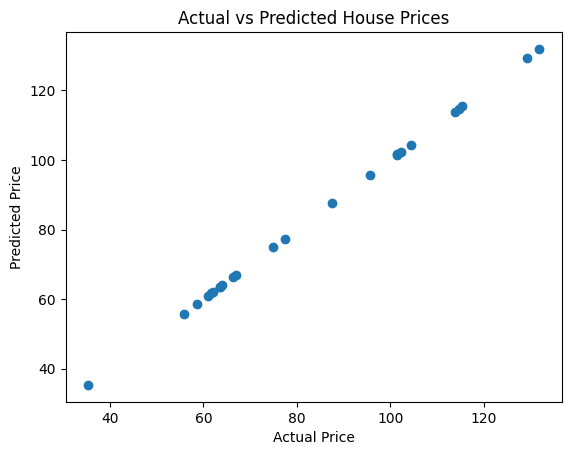

In [ ]:
# Plot Actual vs Predicted Prices

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()